In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
columns = [
    'duration', 'protocol_type', 'service', 'flag', 'src_bytes',
    'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot',
    'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell',
    'su_attempted', 'num_root', 'num_file_creations', 'num_shells',
    'num_access_files', 'num_outbound_cmds', 'is_host_login',
    'is_guest_login', 'count', 'srv_count', 'serror_rate',
    'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate',
    'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count',
    'dst_host_srv_count', 'dst_host_same_srv_rate',
    'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
    'dst_host_srv_diff_host_rate', 'dst_host_serror_rate',
    'dst_host_srv_serror_rate', 'dst_host_rerror_rate',
    'dst_host_srv_rerror_rate', 'label', 'difficulty'
]

In [11]:
import pandas as pd

def load_arff_as_df(filepath):
    rows = []
    columns = []
    in_data = False

    with open(filepath, 'r') as f:
        for line in f:
            line = line.strip()

            # Skip empty lines and comments
            if not line or line.startswith('%'):
                continue

            # Collect column names
            if line.lower().startswith('@attribute'):
                col_name = line.split()[1].strip("'")
                columns.append(col_name)

            # Start reading data
            elif line.lower().startswith('@data'):
                in_data = True

            elif in_data:
                # Clean and split each row
                values = [v.strip().strip("'") for v in line.split(',')]
                rows.append(values)

    df = pd.DataFrame(rows, columns=columns)
    return df

# Load both files
train_df = load_arff_as_df('../data/raw/KDDTrain2+.csv')
test_df  = load_arff_as_df('../data/raw/KDDTest1+.csv')

# Rename label column
train_df.rename(columns={'class': 'label'}, inplace=True)
test_df.rename(columns={'class': 'label'},  inplace=True)

print("Train shape:", train_df.shape)
print("Test shape: ", test_df.shape)
print(train_df['protocol_type'].unique())
train_df.head()

Train shape: (125973, 42)
Test shape:  (22544, 42)
<StringArray>
['tcp', 'udp', 'icmp']
Length: 3, dtype: str


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,25,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal
1,0,udp,other,SF,146,0,0,0,0,0,...,1,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal
2,0,tcp,private,S0,0,0,0,0,0,0,...,26,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,anomaly
3,0,tcp,http,SF,232,8153,0,0,0,0,...,255,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal
4,0,tcp,http,SF,199,420,0,0,0,0,...,255,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal


In [4]:
# Check shape, label values, missing data
print("Train shape:", train_df.shape)
print("Test shape: ", test_df.shape)
print("\nUnique labels:", train_df['label'].unique())
print("\nLabel distribution:\n", train_df['label'].value_counts())
print("\nMissing values:", train_df.isnull().sum().sum())
print("\nColumn data types:\n", train_df.dtypes.value_counts())

Train shape: (125973, 42)
Test shape:  (22544, 42)

Unique labels: <StringArray>
['normal', 'anomaly']
Length: 2, dtype: str

Label distribution:
 label
normal     67343
anomaly    58630
Name: count, dtype: int64

Missing values: 0

Column data types:
 str    42
Name: count, dtype: int64


In [12]:
# These columns should be numeric
numeric_cols = [
    'duration', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment',
    'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised',
    'root_shell', 'su_attempted', 'num_root', 'num_file_creations',
    'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login',
    'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate',
    'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate',
    'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count',
    'dst_host_same_srv_rate', 'dst_host_diff_srv_rate',
    'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate',
    'dst_host_serror_rate', 'dst_host_srv_serror_rate',
    'dst_host_rerror_rate', 'dst_host_srv_rerror_rate'
]

train_df[numeric_cols] = train_df[numeric_cols].apply(pd.to_numeric)
test_df[numeric_cols]  = test_df[numeric_cols].apply(pd.to_numeric)

print("✅ Data types fixed!")
print(train_df.dtypes)

✅ Data types fixed!
duration                         int64
protocol_type                      str
service                            str
flag                               str
src_bytes                        int64
dst_bytes                        int64
land                             int64
wrong_fragment                   int64
urgent                           int64
hot                              int64
num_failed_logins                int64
logged_in                        int64
num_compromised                  int64
root_shell                       int64
su_attempted                     int64
num_root                         int64
num_file_creations               int64
num_shells                       int64
num_access_files                 int64
num_outbound_cmds                int64
is_host_login                    int64
is_guest_login                   int64
count                            int64
srv_count                        int64
serror_rate                    float64
srv_s

In [13]:
print(train_df.describe())

           duration     src_bytes     dst_bytes           land  \
count  125973.00000  1.259730e+05  1.259730e+05  125973.000000   
mean      287.14465  4.556674e+04  1.977911e+04       0.000198   
std      2604.51531  5.870331e+06  4.021269e+06       0.014086   
min         0.00000  0.000000e+00  0.000000e+00       0.000000   
25%         0.00000  0.000000e+00  0.000000e+00       0.000000   
50%         0.00000  4.400000e+01  0.000000e+00       0.000000   
75%         0.00000  2.760000e+02  5.160000e+02       0.000000   
max     42908.00000  1.379964e+09  1.309937e+09       1.000000   

       wrong_fragment         urgent            hot  num_failed_logins  \
count   125973.000000  125973.000000  125973.000000      125973.000000   
mean         0.022687       0.000111       0.204409           0.001222   
std          0.253530       0.014366       2.149968           0.045239   
min          0.000000       0.000000       0.000000           0.000000   
25%          0.000000       0.00000

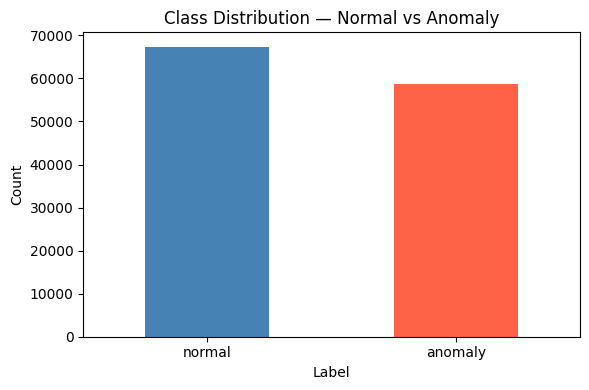

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
train_df['label'].value_counts().plot(kind='bar', color=['steelblue','tomato'])
plt.title('Class Distribution — Normal vs Anomaly')
plt.xlabel('Label')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../docs/plot_class_distribution.png')
plt.show()

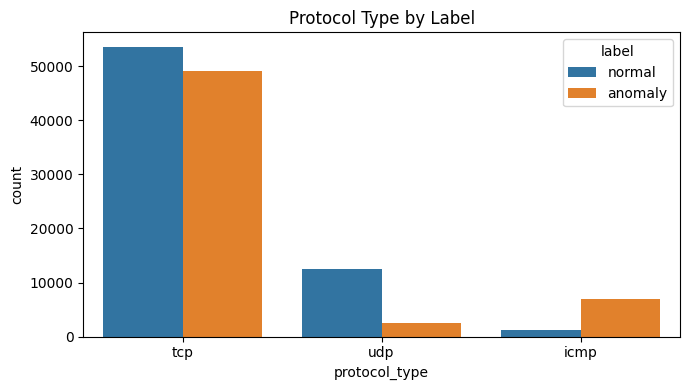

In [16]:
plt.figure(figsize=(7,4))
sns.countplot(data=train_df, x='protocol_type', hue='label')
plt.title('Protocol Type by Label')
plt.tight_layout()
plt.savefig('../docs/plot_protocol_vs_label.png')
plt.show()

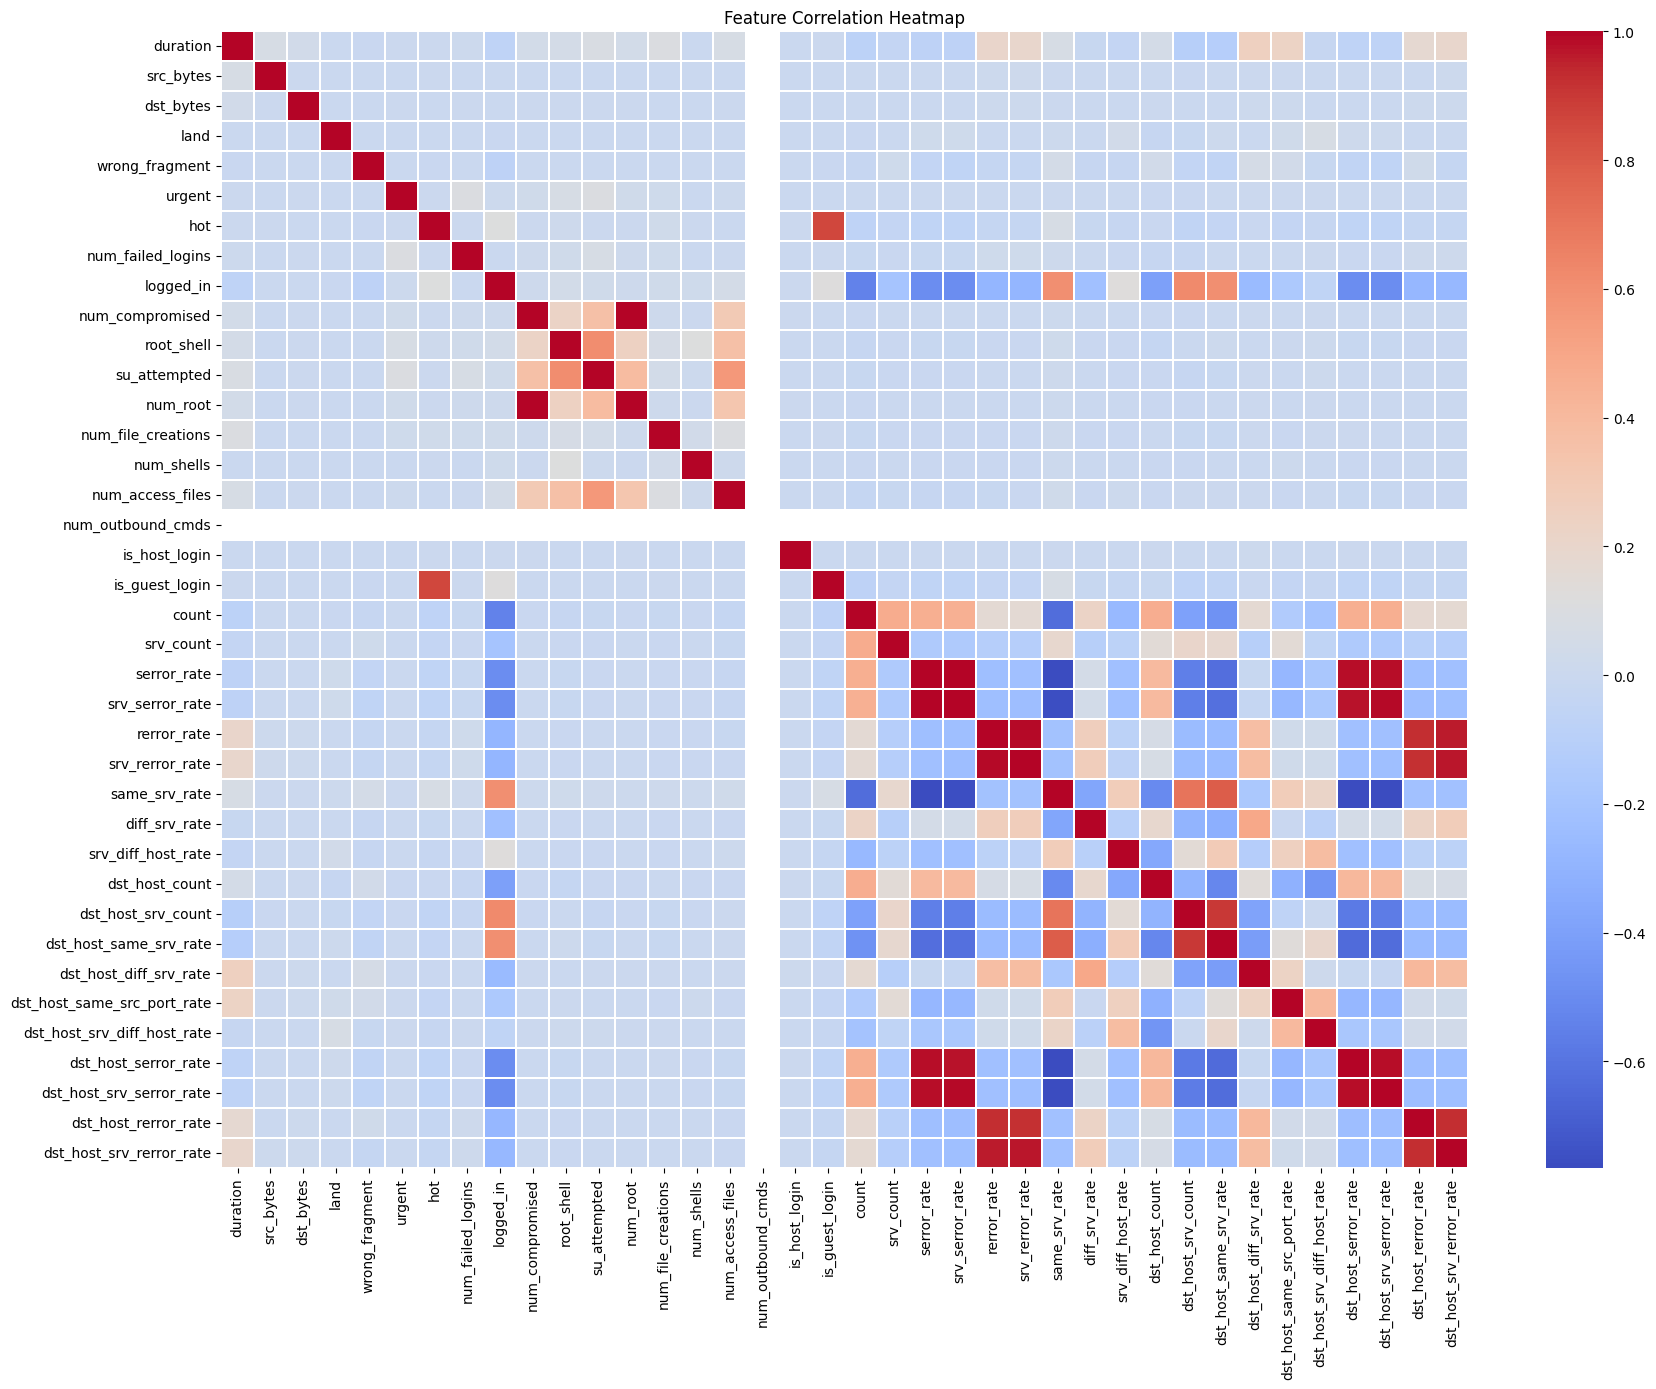

In [17]:
plt.figure(figsize=(18,14))
sns.heatmap(train_df[numeric_cols].corr(), cmap='coolwarm', linewidths=0.3)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.savefig('../docs/plot_correlation_heatmap.png')
plt.show()